In [1]:
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from typing import Annotated, Sequence, TypedDict

In [2]:
load_dotenv()

True

In [3]:
collection_name = "stock_market"
persist_directory = "./vectorized_data/"
pdf_path = "./data/Stock_Market_Performance_2024.pdf"
system_prompt = """
You are an intelligent AI assistant who answers questions about the Stock Market performance in 2024 based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the stock market performance data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific pages and parts of the documents you use in your answers.
"""

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small") #text-embedding-3-large

if(not os.path.exists(pdf_path)):
    raise FileNotFoundError(f"PDF file not found at: {pdf_path}")

pdf_loader = PyPDFLoader(pdf_path)

try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {str(e)}")
    raise

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000
    , chunk_overlap=200
)

pages_split = text_splitter.split_documents(pages)

if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

try:
    vector_store = Chroma.from_documents(
        documents=pages_split
        , embedding=embeddings
        , persist_directory=persist_directory
        , collection_name=collection_name
    )
    print(f"Created ChromaDB vector store in '{persist_directory}'")
except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise

retriever = vector_store.as_retriever(
    search_type = "similarity"
    , search_kwargs={"k":5}
)



PDF has been loaded and has 9 pages
Created ChromaDB vector store in './vectorized_data/'


In [5]:
llm = ChatOpenAI(model=os.getenv("OPENAI_MODEL"), temperature=0)

@tool
def retriever_tool(query:str)-> str:
    """This tool searches and returns the information from the Stock Market Performance 2024 document."""

    docs = retriever.invoke(query)

    if(not docs):
        return "I found no relevant information tin the Stock Market Performance 2024 document."
    
    results = []

    for index, doc in enumerate(docs):
        results.append(f"Document {index+1} of {len(docs)}:\n {doc.page_content}")

    return "\n\n".join(results)

tools = [retriever_tool]
tools_dict = {our_tool.name:our_tool for our_tool in tools}

llm = llm.bind_tools(tools)

In [6]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state["messages"][-1]
    bool_value = ("retriever_tool" in str(result)) and (len(result.tool_calls) > 0)
    return bool_value


# LLM
def call_llm(state:AgentState)->AgentState:
    print("CALL LLM")
    """Function to call the LLM with the current state."""
    messages = list(state["messages"])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {"messages":[message]}


def take_action(state:AgentState)->AgentState:
    """Execute tool calls from the LLM's response"""

    tool_calls = state["messages"][-1].tool_calls
    results = []

    for t in tool_calls:
        print(f"Calling tool:{t['name']} with query: {t['args'].get('query','No query provided')}")

        if(not t["name"] in tools_dict):
            print(f"Tool: {t['name']} does not exist")
            result = "Incorrect Tool Name, please retry and select tool from list of available tools"
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query',''))
            print(f"Result lengthL {len(str(result))}")

        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools execution complete. Back to the model!")
    return {'messages':results}

In [7]:
########################

graph = StateGraph(AgentState)
graph.add_node("llm_name",call_llm)
graph.add_node("retriever_agent_name",take_action)
graph.add_edge(START, "llm_name")

graph.add_conditional_edges(
    "llm_name"
    , should_continue
    ,{
        True:"retriever_agent_name"
        , False:END
    }
)

graph.add_edge("retriever_agent_name","llm_name")
rag_agent = graph.compile()



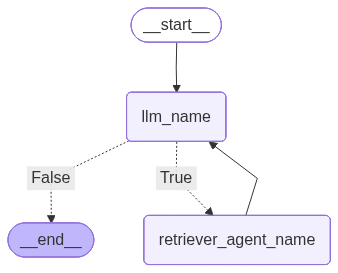

In [8]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [9]:
def running_agent():
    print("**** RAG AGENT ****")

    while(True):
        user_input = input("\n\nWhat is your question?:")

        if(user_input.lower() in ["exit","quit"]):
            break

        messages = [HumanMessage(content=user_input)]

        result= rag_agent.invoke({"messages":messages})

        print("\n\n**** ANSWER ****")
        print(result["messages"][-1].content)

running_agent()        

**** RAG AGENT ****
CALL LLM
Calling tool:retriever_tool with query: number of companies mentioned in the document
Result lengthL 5063
Tools execution complete. Back to the model!
CALL LLM
Calling tool:retriever_tool with query: number of companies mentioned in the document
Result lengthL 5063
Tools execution complete. Back to the model!
CALL LLM


**** ANSWER ****
The document mentions a total of seven companies, collectively referred to as the "Magnificent 7." These companies are Apple, Microsoft, Alphabet (Google), Amazon, Meta (Facebook), Nvidia, and Tesla. (See pages 1-5, sections discussing the "Magnificent 7").
CALL LLM
Calling tool:retriever_tool with query: performance of Per Company in 2024
Result lengthL 4713
Tools execution complete. Back to the model!
CALL LLM


**** ANSWER ****
The retrieved documents do not contain specific information about a company named "Pero" in 2024. Instead, they focus on other companies such as Meta and Tesla, with detailed performance summaries.